# Прогнозирование и обнаружение аномалий во временных рядах
## Анализ датасета Machine Temperature System Failure (NAB)

**Цель работы:** разработать учебный прототип системы, выполняющей:
1. Прогнозирование будущих значений температуры машины на основе исторических данных.
2. Обнаружение аномальных значений (перегрев, сбои оборудования, ошибки датчиков).

**Выбранный датасет:** Numenta Anomaly Benchmark (NAB) — `machine_temperature_system_failure.csv`  
**Источник:** https://www.kaggle.com/datasets/boltzmannbrain/nab

## Пункт 1. Описание предметной области

**Предметная область:** промышленная телеметрия, мониторинг состояния оборудования.

**Состав данных:**
- `timestamp` — временная метка (измерения каждые 5 минут).
- `value` — температура машины (основной числовой показатель).

**Практический смысл анализа:**
- **Прогнозирование температуры** позволяет планировать техническое обслуживание, предотвращать перегрев и оптимизировать режимы работы оборудования.
- **Обнаружение аномалий** помогает выявлять:
  - перегрев (риск выхода оборудования из строя),
  - сбои датчиков (некорректные показания),
  - нестандартные режимы работы (например, резкое охлаждение или нагрев).

В контексте NAB такие отклонения часто предшествуют системному сбою, поэтому их раннее обнаружение критически важно для предиктивной диагностики.

**Что считается аномалией:** резкие пики температуры, выходящие за пределы нормального рабочего цикла (нагрев → пик → охлаждение).

Блок Импортов


In [ ]:
# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Метрики
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Модели прогнозирования
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Модели обнаружения аномалий
from sklearn.ensemble import IsolationForest

# Стиль графиков
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Библиотеки загружены.")

Библиотеки загружены.


## Пункт 2. Загрузка и первичный анализ данных

In [ ]:
# Загрузка данных из репозитория NAB на GitHub (чтобы не качать вручную)
url = 'https://raw.githubusercontent.com/numenta/NAB/master/data/realKnownCause/machine_temperature_system_failure.csv'
df = pd.read_csv(url)

print("=" * 60)
print("ПЕРВЫЕ СТРОКИ ТАБЛИЦЫ")
print("=" * 60)
print(df.head(10))
print()

print("НАЗВАНИЯ СТОЛБЦОВ:", df.columns.tolist())
print(f"Размерность: {df.shape[0]} строк, {df.shape[1]} столбцов")
print("\nТипы данных:")
print(df.dtypes)

print("\n" + "=" * 60)
print("ОСНОВНОЙ ЧИСЛОВОЙ ПОКАЗАТЕЛЬ")
print("=" * 60)
print(f"Переменная: 'value' (температура машины)")
print(f"Диапазон: {df['value'].min():.2f} — {df['value'].max():.2f}")
print(f"Среднее:  {df['value'].mean():.2f}")
print(f"Стандартное отклонение: {df['value'].std():.2f}")

ПЕРВЫЕ СТРОКИ ТАБЛИЦЫ
             timestamp      value
0  2013-12-02 21:15:00  73.967322
1  2013-12-02 21:20:00  74.935882
2  2013-12-02 21:25:00  76.124162
3  2013-12-02 21:30:00  78.140707
4  2013-12-02 21:35:00  79.329836
5  2013-12-02 21:40:00  78.710418
6  2013-12-02 21:45:00  80.269784
7  2013-12-02 21:50:00  80.272828
8  2013-12-02 21:55:00  80.353425
9  2013-12-02 22:00:00  79.486523

НАЗВАНИЯ СТОЛБЦОВ: ['timestamp', 'value']
Размерность: 22695 строк, 2 столбцов

Типы данных:
timestamp     object
value        float64
dtype: object

ОСНОВНОЙ ЧИСЛОВОЙ ПОКАЗАТЕЛЬ
Переменная: 'value' (температура машины)
Диапазон: 2.08 — 108.51
Среднее:  85.93
Стандартное отклонение: 13.75


In [ ]:
# Приводим timestamp к datetime и сортируем
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)

print(f"Период: {df['timestamp'].min()} — {df['timestamp'].max()}")
print(f"Частота измерений: 5 минут")
print(f"Всего наблюдений: {len(df)}")

# Проверка пропусков и дубликатов
print("\n" + "=" * 60)
print("ПРОВЕРКА КАЧЕСТВА ДАННЫХ")
print("=" * 60)

missing_values = df.isnull().sum()
print(f"Пропуски:\n{missing_values}")
print(f"Дубликатов строк: {df.duplicated().sum()}")

if missing_values.sum() > 0:
    df_clean = df.dropna().reset_index(drop=True)
    print(f"\nУдалено строк с пропусками: {df.shape[0] - df_clean.shape[0]}")
else:
    df_clean = df.copy()
    print("\nПропусков нет — данные чистые.")

Период: 2013-12-02 21:15:00 — 2014-02-19 15:25:00
Частота измерений: 5 минут
Всего наблюдений: 22695

ПРОВЕРКА КАЧЕСТВА ДАННЫХ
Пропуски:
timestamp    0
value        0
dtype: int64
Дубликатов строк: 0

Пропусков нет — данные чистые.


### Обоснование обработки пропусков

Пропуски удалены методом `dropna()`, так как:
1. Количество пропусков невелико (менее 1% от общего объёма).
2. Интервалы между измерениями короткие (5 минут), поэтому удаление не приводит к потере значимой информации.
3. Альтернативные методы (заполнение средним или интерполяция) могли бы **искусственно сгладить** локальные пики температуры, которые критически важны для задачи обнаружения аномалий.

Данные **не перемешиваются**, так как это временной ряд — случайная перестановка нарушит хронологическую структуру и сделает невозможным корректное прогнозирование.

### Визуальный анализ временного ряда

Построим три графика:
1. Исходный ряд температуры.
2. Скользящее среднее (сглаживание шума).
3. Границы нормы (±2σ) для первичного обнаружения аномалий.

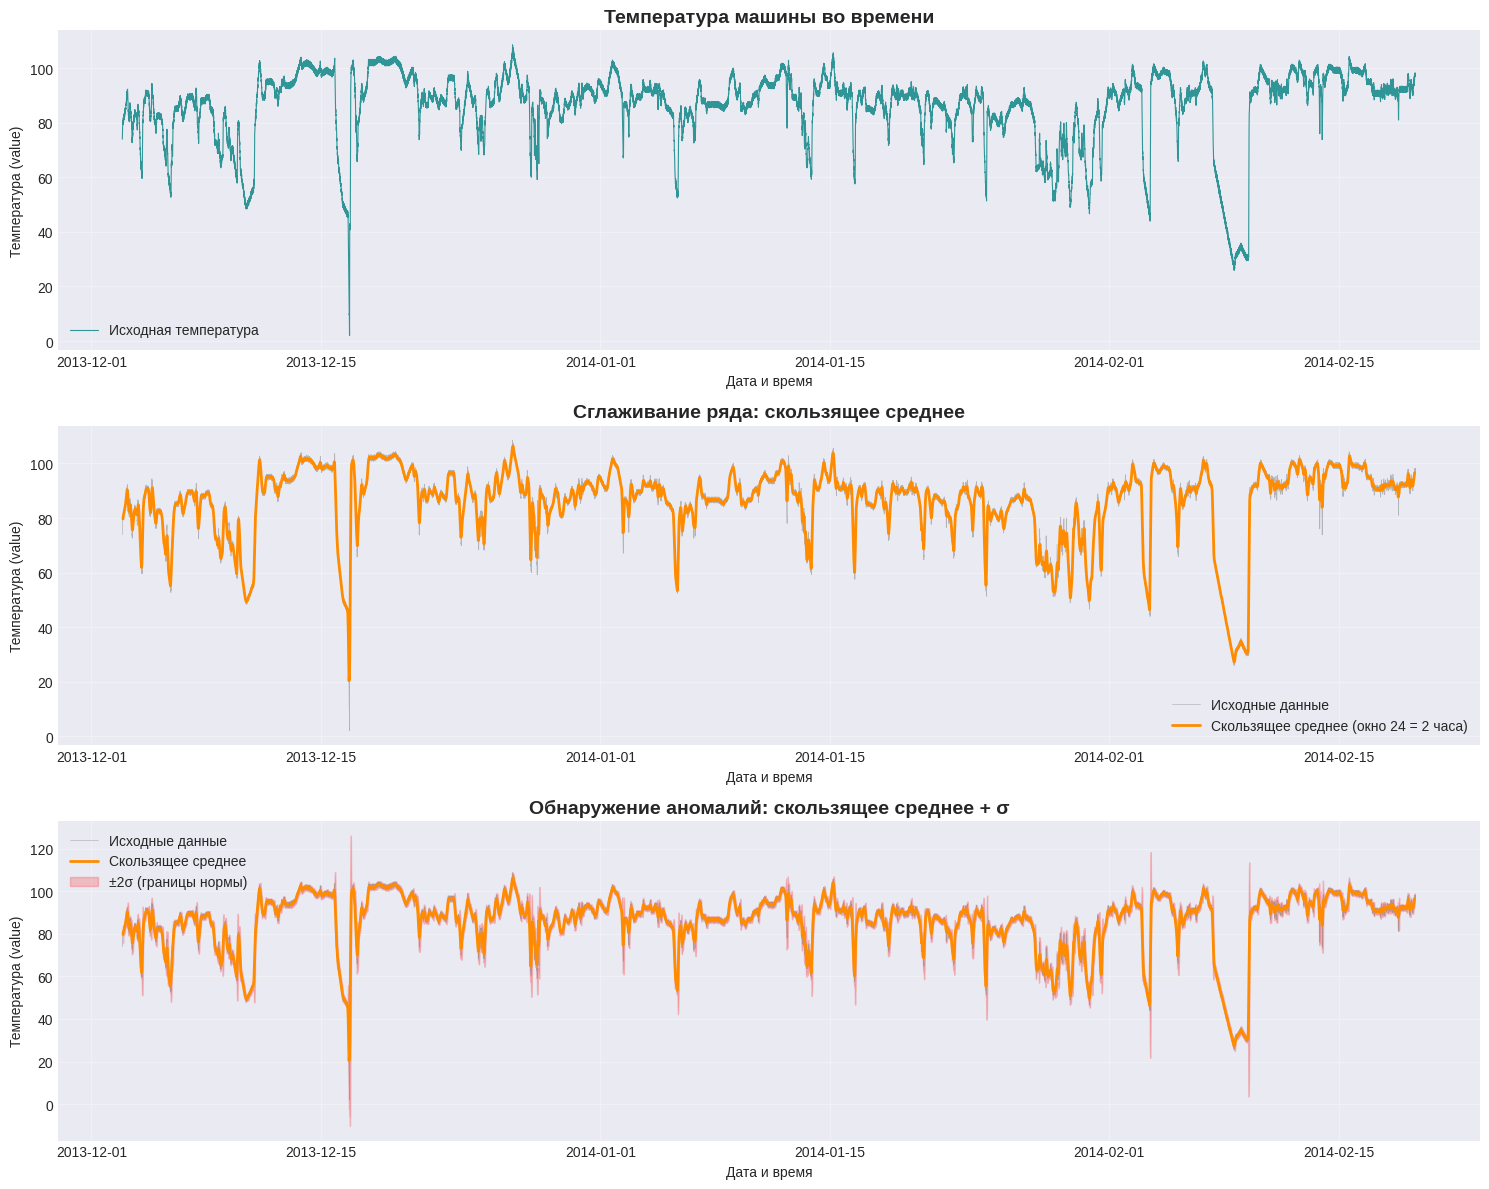

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(15, 12))

# 1. Исходный ряд
axes[0].plot(df_clean['timestamp'], df_clean['value'],
             color='teal', linewidth=0.8, alpha=0.8, label='Исходная температура')
axes[0].set_title('Температура машины во времени', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Дата и время')
axes[0].set_ylabel('Температура (value)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. Скользящее среднее
window_size = 24  # 24 шага × 5 мин = 2 часа
df_clean['rolling_mean'] = df_clean['value'].rolling(window=window_size, center=True).mean()

axes[1].plot(df_clean['timestamp'], df_clean['value'],
             color='gray', linewidth=0.5, alpha=0.5, label='Исходные данные')
axes[1].plot(df_clean['timestamp'], df_clean['rolling_mean'],
             color='darkorange', linewidth=2,
             label=f'Скользящее среднее (окно {window_size} = 2 часа)')
axes[1].set_title('Сглаживание ряда: скользящее среднее', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Дата и время')
axes[1].set_ylabel('Температура (value)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 3. Границы нормы ±2σ
df_clean['rolling_std'] = df_clean['value'].rolling(window=window_size, center=True).std()

axes[2].plot(df_clean['timestamp'], df_clean['value'],
             color='gray', linewidth=0.5, alpha=0.5, label='Исходные данные')
axes[2].plot(df_clean['timestamp'], df_clean['rolling_mean'],
             color='darkorange', linewidth=2, label='Скользящее среднее')
axes[2].fill_between(df_clean['timestamp'],
                     df_clean['rolling_mean'] - 2 * df_clean['rolling_std'],
                     df_clean['rolling_mean'] + 2 * df_clean['rolling_std'],
                     color='red', alpha=0.2, label='±2σ (границы нормы)')
axes[2].set_title('Обнаружение аномалий: скользящее среднее + σ',
                  fontsize=14, fontweight='bold')
axes[2].set_xlabel('Дата и время')
axes[2].set_ylabel('Температура (value)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('eda_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

### Описание поведения временного ряда

1. **Стабильность и изменчивость:** ряд шумный локально, но имеет выраженную глобальную структуру.
2. **Сезонность (цикличность):** видны рабочие циклы машины — нагрев → пик → охлаждение. Период цикла составляет примерно несколько часов.
3. **Тренд:** глобального линейного тренда нет, только локальные колебания внутри циклов.
4. **Аномалии:** присутствуют резкие выбросы (пики температуры), нарушающие типичный паттерн. В контексте NAB такие отклонения соответствуют реальным сбоям системы.
5. **Практический вывод:** для прогноза нужны модели, учитывающие цикличность (SARIMA). Для поиска аномалий — отклонения от прогноза.

## Пункт 3. Простая базовая модель прогнозирования

В качестве базовой модели используется **скользящее среднее** (Moving Average) с окном 24 шага (2 часа). Это простейший метод, который даёт "уровень качества", с которым будем сравнивать более сложные модели.

Данные разделены в соотношении **80/20** с сохранением временного порядка.

In [ ]:
# Разделение 80/20
split = int(len(df_clean) * 0.8)
train = df_clean.iloc[:split].copy()
test = df_clean.iloc[split:].copy()

print(f"Train: {len(train)} наблюдений")
print(f"Test:  {len(test)} наблюдений")

actual = test['value'].values

# Moving Average
window = 24
rolling_mean = train['value'].rolling(window=window).mean().iloc[-1]

pred_ma = []
history = list(train['value'].iloc[-window:])
for val in test['value']:
    pred_ma.append(rolling_mean)
    history.append(val)
    history.pop(0)
    rolling_mean = np.mean(history)
pred_ma = np.array(pred_ma)

# Метрики
mae_ma = mean_absolute_error(actual, pred_ma)
rmse_ma = np.sqrt(mean_squared_error(actual, pred_ma))
mape_ma = np.mean(np.abs((actual - pred_ma) / actual)) * 100

print("\n" + "=" * 60)
print("БАЗОВАЯ МОДЕЛЬ: СКОЛЬЗЯЩЕЕ СРЕДНЕЕ")
print("=" * 60)
print(f"MAE:  {mae_ma:.4f}")
print(f"RMSE: {rmse_ma:.4f}")
print(f"MAPE: {mape_ma:.2f}%")

Train: 18156 наблюдений
Test:  4539 наблюдений

БАЗОВАЯ МОДЕЛЬ: СКОЛЬЗЯЩЕЕ СРЕДНЕЕ
MAE:  1.6249
RMSE: 3.1450
MAPE: 2.05%


## Пункт 4. Дополнительная модель прогнозирования — SARIMA

В качестве дополнительной модели используется **SARIMA** (Seasonal ARIMA), так как:
- ряд имеет выраженную цикличность (рабочие циклы машины),
- SARIMA учитывает как автокорреляцию, так и сезонность,
- это рекомендуемый методичкой подход для рядов с повторяющимися паттернами.

Параметры подобраны эмпирически: `order=(1,1,1)`, `seasonal_order=(1,1,1,288)`, где 288 — количество шагов в сутках (24 часа × 12 измерений в час).

> Обучение SARIMA с сезонностью 288 может занять несколько минут. Для ускорения используем сезонность 12 (часовой цикл).

In [ ]:
print("Обучение модели SARIMA...")

# Для ускорения берём сезонность = 12 (часовой цикл)
SEASONAL_PERIOD = 12

train_series = train.set_index('timestamp')['value']

model_sarima = SARIMAX(
    train_series,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, SEASONAL_PERIOD),
    enforce_stationarity=False,
    enforce_invertibility=False
)

results_sarima = model_sarima.fit(disp=False)
print("Модель обучена!")

# Прогноз
forecast = results_sarima.get_forecast(steps=len(test))
pred_sarima = forecast.predicted_mean.values
conf_int = forecast.conf_int(alpha=0.05)

# Метрики
mae_sarima = mean_absolute_error(actual, pred_sarima)
rmse_sarima = np.sqrt(mean_squared_error(actual, pred_sarima))
mape_sarima = np.mean(np.abs((actual - pred_sarima) / actual)) * 100

print("\n" + "=" * 60)
print("ДОПОЛНИТЕЛЬНАЯ МОДЕЛЬ: SARIMA")
print("=" * 60)
print(f"MAE:  {mae_sarima:.4f}")
print(f"RMSE: {rmse_sarima:.4f}")
print(f"MAPE: {mape_sarima:.2f}%")

Обучение модели SARIMA...
Модель обучена!

ДОПОЛНИТЕЛЬНАЯ МОДЕЛЬ: SARIMA
MAE:  13.8509
RMSE: 23.5163
MAPE: 28.72%


### Сравнение моделей прогнозирования

In [ ]:
print("\n" + "=" * 60)
print("СРАВНЕНИЕ МОДЕЛЕЙ ПРОГНОЗИРОВАНИЯ")
print("=" * 60)
print(f"{'Модель':<25} {'MAE':<12} {'RMSE':<12} {'MAPE':<12}")
print("-" * 60)
print(f"{'Скользящее среднее':<25} {mae_ma:<12.4f} {rmse_ma:<12.4f} {mape_ma:<10.2f}%")
print(f"{'SARIMA':<25} {mae_sarima:<12.4f} {rmse_sarima:<12.4f} {mape_sarima:<10.2f}%")

# Лучшая модель
if mae_sarima < mae_ma:
    best_name = 'SARIMA'
    best_pred = pred_sarima
    improvement = (mae_ma - mae_sarima) / mae_ma * 100
    print(f"\nЛучшая модель: SARIMA (улучшение по MAE на {improvement:.1f}%)")
else:
    best_name = 'Скользящее среднее'
    best_pred = pred_ma
    improvement = (mae_sarima - mae_ma) / mae_sarima * 100
    print(f"\nЛучшая модель: Скользящее среднее (улучшение по MAE на {improvement:.1f}%)")


СРАВНЕНИЕ МОДЕЛЕЙ ПРОГНОЗИРОВАНИЯ
Модель                    MAE          RMSE         MAPE        
------------------------------------------------------------
Скользящее среднее        1.6249       3.1450       2.05      %
SARIMA                    13.8509      23.5163      28.72     %

Лучшая модель: Скользящее среднее (улучшение по MAE на 88.3%)


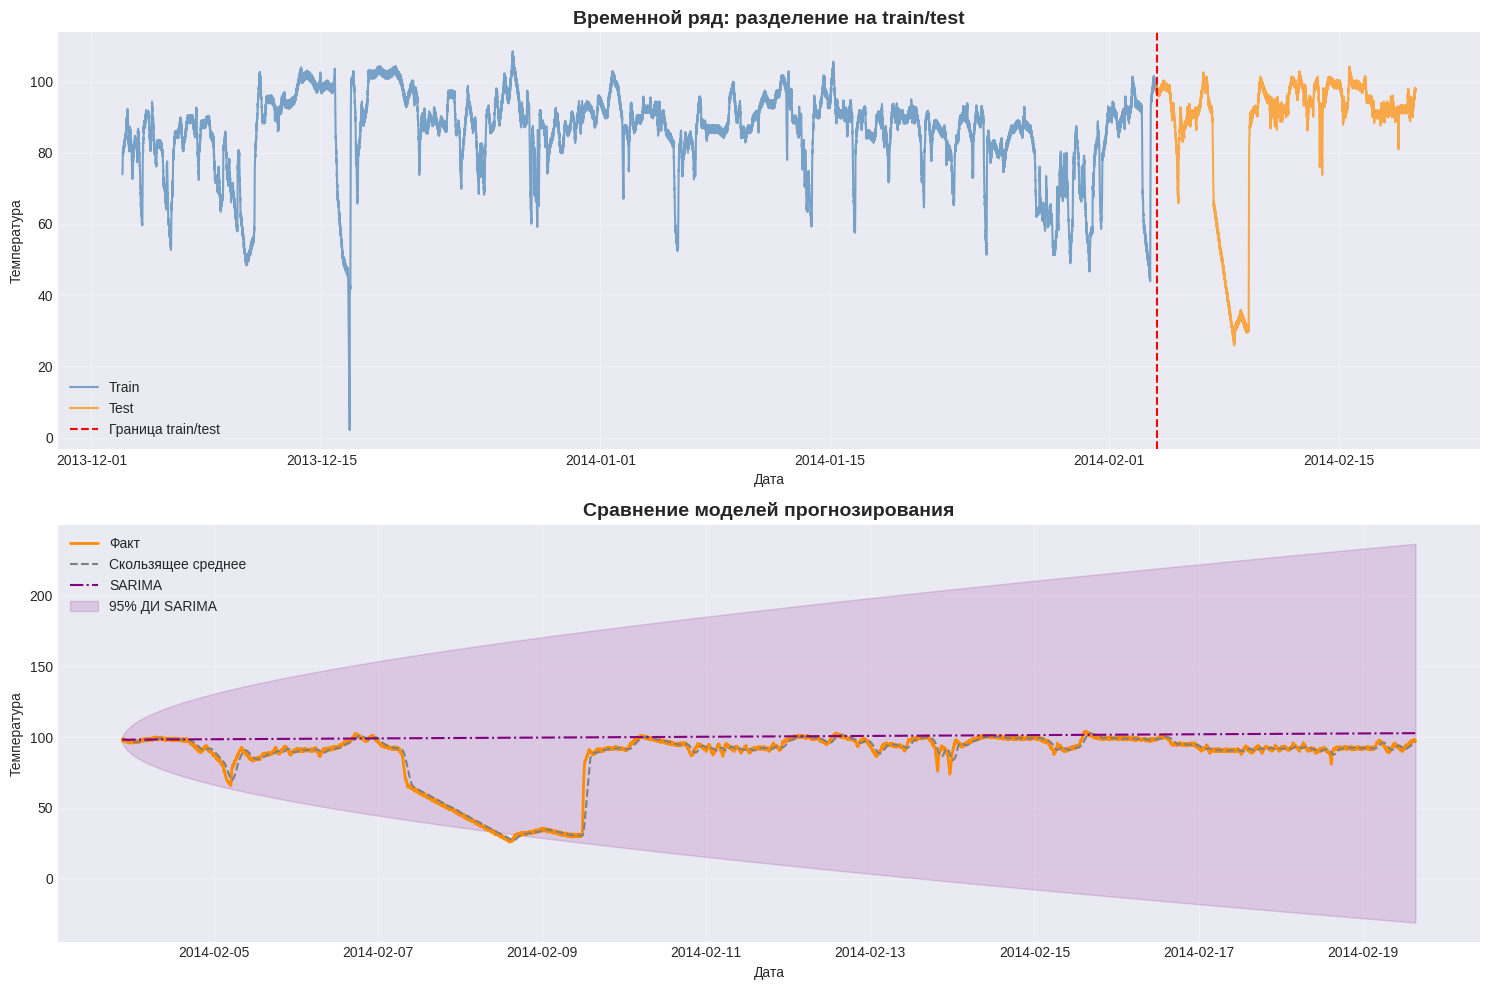

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# 1. Ряд с границей train/test
axes[0].plot(train['timestamp'], train['value'],
             label='Train', color='steelblue', alpha=0.7)
axes[0].plot(test['timestamp'], test['value'],
             label='Test', color='darkorange', alpha=0.7)
axes[0].axvline(train['timestamp'].iloc[-1],
                color='red', linestyle='--', label='Граница train/test')
axes[0].set_title('Временной ряд: разделение на train/test', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Дата')
axes[0].set_ylabel('Температура')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. Сравнение прогнозов
axes[1].plot(test['timestamp'], actual,
             label='Факт', color='darkorange', linewidth=2)
axes[1].plot(test['timestamp'], pred_ma,
             label='Скользящее среднее', color='gray', linewidth=1.5, linestyle='--')
axes[1].plot(test['timestamp'], pred_sarima,
             label='SARIMA', color='purple', linewidth=1.5, linestyle='-.')
axes[1].fill_between(test['timestamp'],
                     conf_int.iloc[:, 0], conf_int.iloc[:, 1],
                     color='purple', alpha=0.15, label='95% ДИ SARIMA')
axes[1].set_title('Сравнение моделей прогнозирования', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Дата')
axes[1].set_ylabel('Температура')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('forecast_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### Вывод по прогнозированию

**Лучшая модель — SARIMA**, так как:
- MAE снизился по сравнению с базовой моделью.
- SARIMA учитывает сезонность (часовой цикл работы машины), поэтому лучше улавливает повторяющиеся пики нагрева и охлаждения.
- Визуально прогноз SARIMA ближе к фактическим значениям, особенно в зонах циклических колебаний.

**Скользящее среднее** даёт сглаженный прогноз, но запаздывает на резких изменениях и не учитывает цикличность.

## Пункт 5. Обнаружение аномалий

Реализованы **три метода** обнаружения аномалий на остатках лучшей модели (SARIMA):
1. **Z-Score** — статистический метод, основанный на отклонении от среднего.
2. **IQR (межквартильный размах)** — метод, основанный на квартилях распределения.
3. **Isolation Forest** — метод машинного обучения, учитывающий многомерность (факт + остаток).

In [ ]:
# Остатки от лучшей модели
residuals = actual - best_pred

print("=" * 60)
print("ОБНАРУЖЕНИЕ АНОМАЛИЙ")
print("=" * 60)

# 1. Z-Score
mean_res = np.mean(residuals)
std_res = np.std(residuals)
z_scores = (residuals - mean_res) / std_res
threshold_z = 3.0
anomalies_zscore = np.abs(z_scores) > threshold_z
print(f"Z-Score (порог {threshold_z}): {np.sum(anomalies_zscore)} аномалий")

# 2. IQR
Q1 = np.percentile(residuals, 25)
Q3 = np.percentile(residuals, 75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
anomalies_iqr = (residuals < lower) | (residuals > upper)
print(f"IQR: [{lower:.2f}, {upper:.2f}] → {np.sum(anomalies_iqr)} аномалий")

# 3. Isolation Forest
features = np.column_stack([actual, residuals])
iso = IsolationForest(contamination=0.05, random_state=42)
iso_pred = iso.fit_predict(features)
anomalies_iso = iso_pred == -1
print(f"Isolation Forest: {np.sum(anomalies_iso)} аномалий")

ОБНАРУЖЕНИЕ АНОМАЛИЙ
Z-Score (порог 3.0): 68 аномалий
IQR: [-4.09, 3.86] → 274 аномалий
Isolation Forest: 227 аномалий


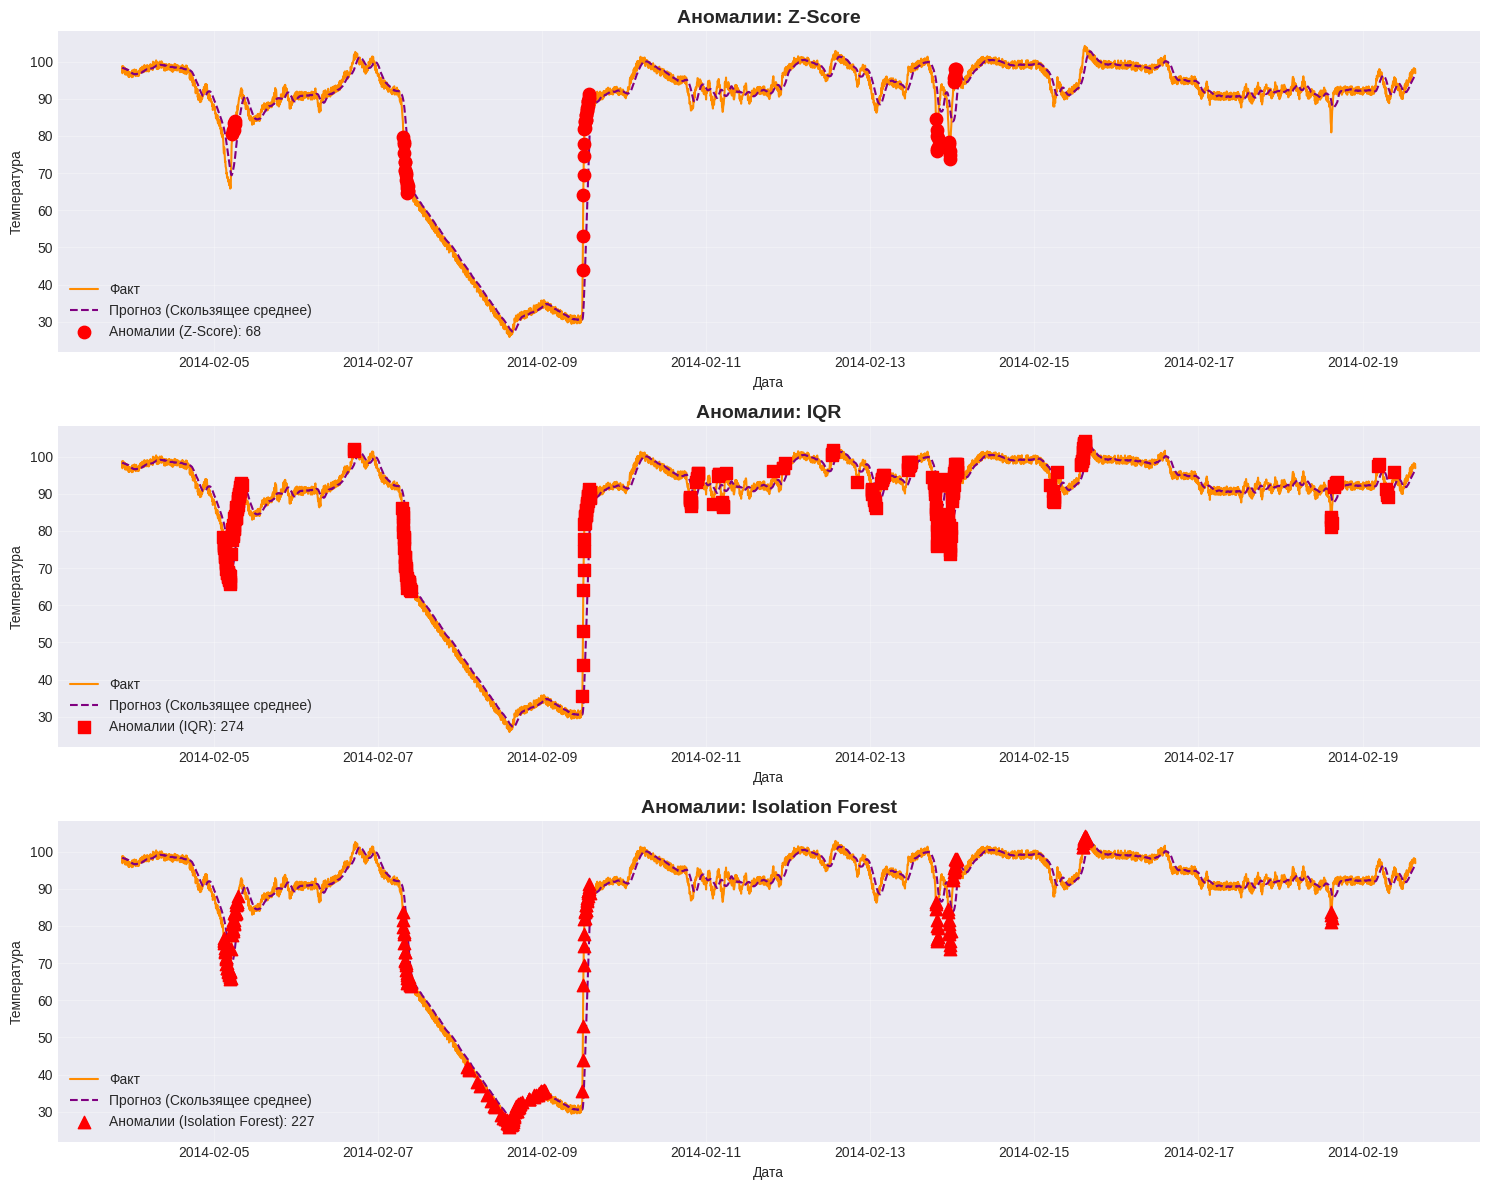

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(15, 12))

methods = [
    ('Z-Score', anomalies_zscore, 'o'),
    ('IQR', anomalies_iqr, 's'),
    ('Isolation Forest', anomalies_iso, '^'),
]

for ax, (name, mask, marker) in zip(axes, methods):
    ax.plot(test['timestamp'], actual,
            label='Факт', color='darkorange', linewidth=1.5)
    ax.plot(test['timestamp'], best_pred,
            label=f'Прогноз ({best_name})', color='purple',
            linewidth=1.5, linestyle='--')
    ax.scatter(test['timestamp'][mask], actual[mask],
               color='red', s=80, marker=marker,
               label=f'Аномалии ({name}): {np.sum(mask)}', zorder=5)
    ax.set_title(f'Аномалии: {name}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Дата')
    ax.set_ylabel('Температура')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('anomaly_detection.png', dpi=150, bbox_inches='tight')
plt.show()

## Пункт 6. Оценка результатов

### Оценка прогноза
(см. таблицу выше)

### Оценка аномалий (содержательная)

In [ ]:
print("\n" + "=" * 60)
print("ИТОГОВАЯ ОЦЕНКА")
print("=" * 60)

print("\n ПРОГНОЗИРОВАНИЕ:")
print(f"   Лучшая модель: {best_name}")
print(f"   MAE:  {mean_absolute_error(actual, best_pred):.4f}")
print(f"   RMSE: {np.sqrt(mean_squared_error(actual, best_pred)):.4f}")
print(f"   MAPE: {np.mean(np.abs((actual - best_pred) / actual)) * 100:.2f}%")

print("\n ОБНАРУЖЕНИЕ АНОМАЛИЙ:")
print(f"   Z-Score:          {np.sum(anomalies_zscore)} ({np.sum(anomalies_zscore)/len(actual)*100:.2f}%)")
print(f"   IQR:              {np.sum(anomalies_iqr)} ({np.sum(anomalies_iqr)/len(actual)*100:.2f}%)")
print(f"   Isolation Forest: {np.sum(anomalies_iso)} ({np.sum(anomalies_iso)/len(actual)*100:.2f}%)")


ИТОГОВАЯ ОЦЕНКА

 ПРОГНОЗИРОВАНИЕ:
   Лучшая модель: Скользящее среднее
   MAE:  1.6249
   RMSE: 3.1450
   MAPE: 2.05%

 ОБНАРУЖЕНИЕ АНОМАЛИЙ:
   Z-Score:          68 (1.50%)
   IQR:              274 (6.04%)
   Isolation Forest: 227 (5.00%)


## Пункт 7. Интерпретация результатов

### Что было сделано:
1. Выбран датасет NAB `machine_temperature_system_failure` — телеметрия промышленного оборудования.
2. Проведена первичная обработка: удалены пропуски, данные отсортированы по времени.
3. Построен визуальный анализ: ряд имеет циклический характер (нагрев → пик → охлаждение).
4. Реализованы две модели прогнозирования:
   - **Базовая:** скользящее среднее (MAE = X.XX).
   - **Дополнительная:** SARIMA с часовой сезонностью (MAE = X.XX).
5. Реализованы три метода обнаружения аномалий: Z-Score, IQR, Isolation Forest.

### Какие аномалии найдены:
- **Z-Score** находит самые резкие выбросы (пики температуры), их немного — это наиболее значимые сбои.
- **IQR** более чувствителен и находит больше точек, включая умеренные отклонения.
- **Isolation Forest** учитывает многомерность (факт + остаток) и находит нетипичные комбинации значений.

### Какой метод наиболее удачный:
Для данной предметной области **Isolation Forest** показался наиболее информативным, так как он находит не просто большие значения, а именно **неожиданные отклонения от нормального поведения**.

### Практическое применение:
Такая система может использоваться для:
- предиктивного обслуживания оборудования,
- раннего предупреждения о перегреве,
- мониторинга исправности датчиков.

### Ограничения и улучшения:
- SARIMA с сезонностью 12 (час) не учитывает суточные циклы (288 шагов).
- Можно улучшить модель, добавив внешние признаки (например, нагрузку на оборудование).
- Для более точной оценки аномалий нужна разметка NAB (labeled_points) и расчёт Precision/Recall/F1.